In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append("/Users/ana/Desktop/takarada/")
from helpers_takarada import * 
from module_takarada import *
import matplotlib
import seaborn as sns
plt.rcParams.update({'savefig.dpi':300, 'axes.labelweight':'normal'})
matplotlib.rcParams['axes.linewidth'] = 0.8
from matplotlib import rc
preamble = r'''\usepackage{physics} \usepackage{upgreek} \usepackage{bm}'''
plt.rc('text.latex', preamble=preamble)
rc('text', usetex=True)

plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['legend.fontsize'] = 12

''' numerical parameters for the self-consistent calculation '''
parameters1 = {'n_pass' : 1e-4,
'epsilon_threshold' : 1e-6,
'N_epsilon' : 5,
'maxiter' : 500,
'eps_last' : 1e-6,
'dmu' : 0.5,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

parameters2 = {'n_pass' : 1e-3,
'epsilon_threshold' : 1e-6,
'N_epsilon' : 5,
'maxiter' : 100,
'eps_last' : 1e-6,
'dmu' : 0.5,
'mix2' : 0.001,
'mix3' : 1.5,
'faktor1' : 0.1,
'max_trials' : 15,
'eps0' : 0.03,
}

def colorFader(c1, c2, mix=0.5):
    c1 = np.array(matplotlib.colors.to_rgb(c1))
    c2 = np.array(matplotlib.colors.to_rgb(c2))
    return matplotlib.colors.to_hex((1-mix)*c1 + mix*c2)

def get_palette_hex(palette_name, N):
    return sns.color_palette(palette_name, n_colors=N).as_hex()

excitonic susceptibility for V_c=0, t12=0

excitonic susceptibility for V_c=0, t12\neq 0 

(np.complex128(0.16037327177241037+7.273831060042313e-19j),
 np.complex128(-0j),
 np.float64(0.6564239418674948))

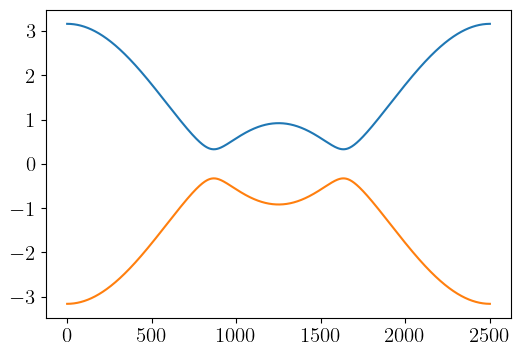

In [535]:
''' 1. generate ground state of some excitonic insulator model '''
a = 1.
b = 0.2

t12 = 0.1
delta = 0.

t = -1.0
t_ = -1.0
Vc = 0.0
Vb = 1.0

mu0 = 0.
include_hartree = True

Nk = 2500

gap = -3
epsilon = 0.5*(gap + 2*t_ + 2*t)
epsilon_ = epsilon

epsilon = 0.55
epsilon_ = -2.45

phys_parameters = [b, t, t_, t12, epsilon, epsilon_, Vb, Vc, delta]
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()
plt.plot(m.energije[1]-m.mu)
plt.plot(m.energije[0]-m.mu)
m.delta_b, m.delta_c, m.gap


In [536]:
''' 2. heat up to a low temperature '''
beta0 = 50
scale = 1.005
betas = beta0/scale**np.arange(1,10)
stops = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]
Ts = 1/betas
maxbrentq = 20

# set parameters below to random values, because I will not compute transport coefficients in this temperature sweep
Nomega, eps, Gammas = 1000, 1e-5, [0.01]

m.run_Tdependence(betas, stops, Gammas, Nomega, eps, maxbrentq, evaluate_transport=False)

started
0.0
49.75124378109453 9.804690677128747e-07 1.0000000000000007 0.1603732389770062 0.0
0.1111111111111111
49.50372515531796 9.804699919180315e-07 1.0000000000000002 0.16037323856472346 0.0
0.2222222222222222
49.2574379654905 9.804693763548755e-07 0.9999999999999996 0.160373238118986 0.0
0.3333333333333333
49.01237608506518 9.804695479953551e-07 1.0000000000000007 0.16037323763681205 0.0
0.4444444444444444
48.76853341797531 9.804705373150924e-07 0.9999999999999997 0.1603732371154485 0.0
0.5555555555555556
48.525903898482895 9.804699291349195e-07 1.0000000000000004 0.16037323655239166 0.0
0.6666666666666666
48.28448149102776 9.804709718563842e-07 0.9999999999999997 0.16037323594392003 0.0
0.7777777777777778
48.04426019007738 9.804703676730142e-07 0.9999999999999999 0.16037323528726785 0.0
0.8888888888888888
47.805234019977505 9.804706104787897e-07 0.9999999999999996 0.1603732345784046 0.0


In [537]:
rhos, thetas = rho_operators(m.K, m.phys_parameters, m.include_hartree)

''' 3. simulate pulz for excitonic susceptibility '''
perturbation_operator = rhos[2]
measure_provider = [rhos[1], rhos[2]]

A0 = 0.003
t0 = 2.0
sigma = 0.01
Omega0 = 0.0
dt = 0.003
t_max = 500
Ncorr = 100
tol = 1e-5

Gamma = 0.01

do_freeze = True
time, measurement, norma, delta_bs, delta_cs = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                                             A0, t0, sigma, Omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma, 64)

do_freeze = False
timeN, measurementN, normaN, delta_bsN, delta_csN = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                                             A0, t0, sigma, Omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma, 64)

0.0
0.00030000120000480004
0.0006000024000096001
0.0009000036000144001
0.0012000048000192002
0.001500006000024
0.0018000072000288001
0.0021000084000336
0.0024000096000384003
0.0027000108000432
0.003000012000048
0.0033000132000528004
0.0036000144000576002
0.0039000156000624
0.0042000168000672
0.004500018000072
0.004800019200076801
0.0051000204000816
0.0054000216000864
0.005700022800091201
0.006000024000096
0.0063000252001008
0.006600026400105601
0.0069000276001104
0.0072000288001152005
0.007500030000120001
0.0078000312001248
0.0081000324001296
0.0084000336001344
0.0087000348001392
0.009000036000144
0.009300037200148801
0.009600038400153601
0.0099000396001584
0.0102000408001632
0.010500042000168
0.0108000432001728
0.011100044400177601
0.011400045600182401
0.0117000468001872
0.012000048000192
0.0123000492001968
0.0126000504002016
0.012900051600206401
0.013200052800211201
0.013500054000216
0.0138000552002208
0.0141000564002256
0.014400057600230401
0.014700058800235201
0.015000060000240002


In [ ]:
''' 4. compute excitonic susceptibitiliy via RPA '''
rhos, thetas = rho_operators(m.K, m.phys_parameters, m.include_hartree)
thetas = -thetas
rhos_tilde = operator_tilde(rhos, m.vecs)
L = 30
deg = 1000
nodes, weights = np.polynomial.legendre.leggauss(deg)
Nop = len(thetas)
I = np.eye(Nop)

Gammas = [0.005]
omegas = np.linspace(0.01, 3.0, 300)
chi_xy0 = np.zeros((len(Gammas), len(omegas)), dtype=np.complex128)
chi_xy = np.zeros_like(chi_xy0)

chi_yy0 = np.zeros_like(chi_xy0)
chi_yy = np.zeros_like(chi_xy0)

determinants = np.zeros((len(Gammas), len(omegas)), dtype=np.complex128)

for g, Gamma in enumerate(Gammas):
    print(g)
    mu_ = m.mu / Gamma
    invt = Gamma / m.Ts[-1]
    for om, omega in enumerate(omegas):
        chi0 = np.zeros((Nop, Nop), dtype=np.complex128)
        pi_w, pi_eps_w = Pi_bubble_tilde_w(m.Nk, omega, m.energije, Gamma, mu_, invt, L, nodes, weights)
        for i in range(Nop):
            for j in range(Nop):
                chi0[i,j] = chi_UV(m.Nk, rhos_tilde[i], rhos_tilde[j], pi_w, pi_eps_w)
        chi_yy0[g,om] = chi0[2,2]
        chi_xy0[g,om] = chi0[1,2]
        mat = I - chi0 @ np.diag(thetas)
        determinants[g,om] = LA.det(mat)
        inv = np.linalg.inv(mat)
        assert np.max(np.abs(inv @ mat - I)) < 1e-10

        x, residuals, rank, sv = np.linalg.lstsq(mat, chi0, rcond=None)

        chi = inv @ chi0
        chi_yy[g,om] = chi[2,2]
        chi_xy[g,om] = chi[1,2]

0


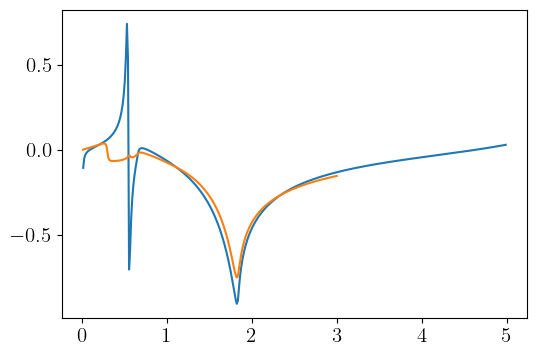

In [547]:
plt.plot(Omega, -Chi_xyN.imag)
plt.plot(omegas, chi_xy.imag[g])

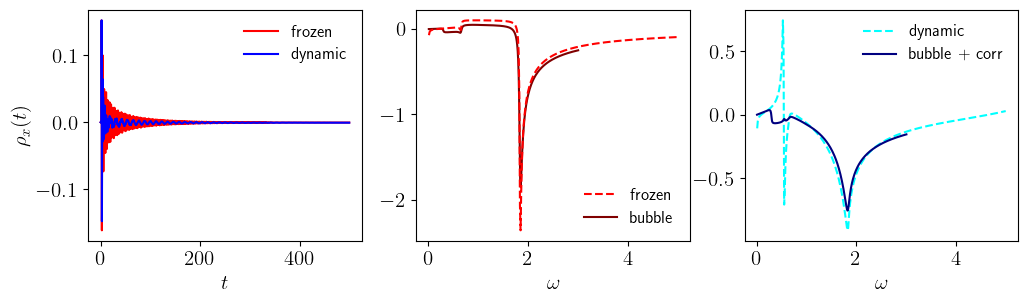

In [546]:
meas_xy = measurement[0] - measurement[0,0]
meas_xyN = measurementN[0] - measurementN[0,0]

pulz = A_pulz(time, A0, t0, sigma, Omega0)
omega_cut = 5
eta = 0.001

Omega, Signal_xy, Pulz = susceptibility(time, meas_xy, pulz, eta, omega_cut, m.Nk)
_, Signal_xyN, _ = susceptibility(timeN, meas_xyN, pulz, eta, omega_cut, m.Nk)

Chi_xy = Signal_xy / Pulz
Chi_xyN = Signal_xyN / Pulz
peakN = Omega[np.argmax(-Chi_xyN.imag)]

fig, ax = plt.subplots(ncols=3, figsize=(12,3))
ax[0].plot(timeN, meas_xy.real, color='red', label='frozen')
ax[0].plot(timeN, meas_xyN.real, color='blue', label='dynamic', )#zorder=-100)
ax[0].set_xlabel(r'$t$', fontsize=15)
ax[0].set_ylabel(r'$\rho_x(t)$', fontsize=15)
ax[0].legend(frameon=False)
g = 0
ax[1].plot(Omega, -Chi_xy.imag, color='red', ls='dashed', zorder=100, label='frozen')
ax[1].plot(omegas, chi_xy0.imag[g], color='maroon', label='bubble')

ax[2].plot(Omega, -Chi_xyN.imag, color='cyan', ls='dashed', label='dynamic')
ax[2].plot(omegas, chi_xy.imag[g], color='navy', label='bubble + corr')
ax[1].legend(frameon=False)

ax[2].legend(frameon=False)

for j in range(1,3):
    ax[j].set_xlabel(r'$\omega$', fontsize=15)






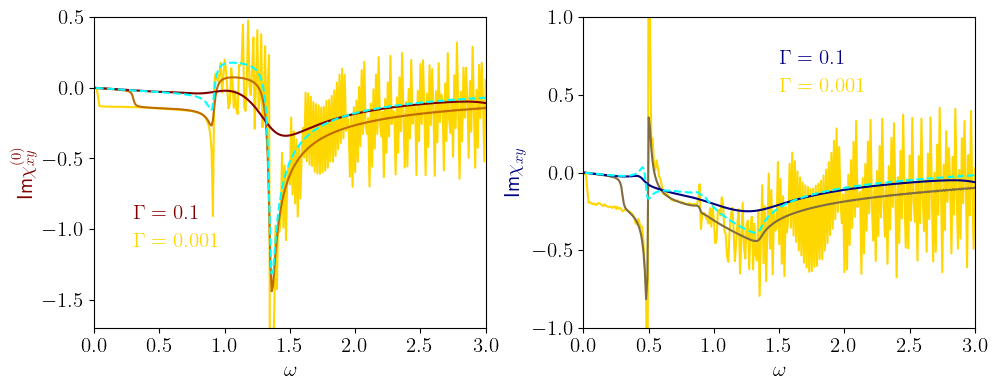

In [430]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4))

pal0 = [colorFader('gold', 'maroon', g/(len(Gammas) - 1)) for g in range(len(Gammas))]
pal = [colorFader('gold', 'navy', g/(len(Gammas) - 1)) for g in range(len(Gammas))]

for g, Gamma in enumerate(Gammas):
    ax[0].plot(omegas, chi_xy0.imag[g], color=pal0[g])
    ax[1].plot(omegas, chi_xy.imag[g], color=pal[g])

ax[0].text(0.1,0.26, rf'$\Gamma={Gammas[0]}$', color=pal0[0],transform=ax[0].transAxes, fontsize=15)
ax[0].text(0.1,0.35, rf'$\Gamma={Gammas[-1]}$', color=pal0[-1],transform=ax[0].transAxes, fontsize=15)
ax[1].text(0.5,0.76, rf'$\Gamma={Gammas[0]}$', color=pal[0],transform=ax[1].transAxes, fontsize=15)
ax[1].text(0.5,0.85, rf'$\Gamma={Gammas[-1]}$', color=pal[-1],transform=ax[1].transAxes, fontsize=15)
for j in range(2):
    ax[j].set_xlabel(r'$\omega$', fontsize=15)
ax[0].set_ylabel(r'$\text{Im}\chi_{xy}^{(0)}$', fontsize=15, color='maroon')
ax[1].set_ylabel(r'$\text{Im}\chi_{xy}$', fontsize=15, color='navy')

ax[0].set_ylim(-1.7,0.5)
ax[1].set_ylim(-1,1)
ax[0].plot(Omega, -Chi_xy.imag, color='cyan', ls='dashed')
ax[1].plot(Omega, -Chi_xyN.imag, color='cyan', ls='dashed')
ax[0].set_xlim(0,3), ax[1].set_xlim(0,3)

plt.tight_layout()

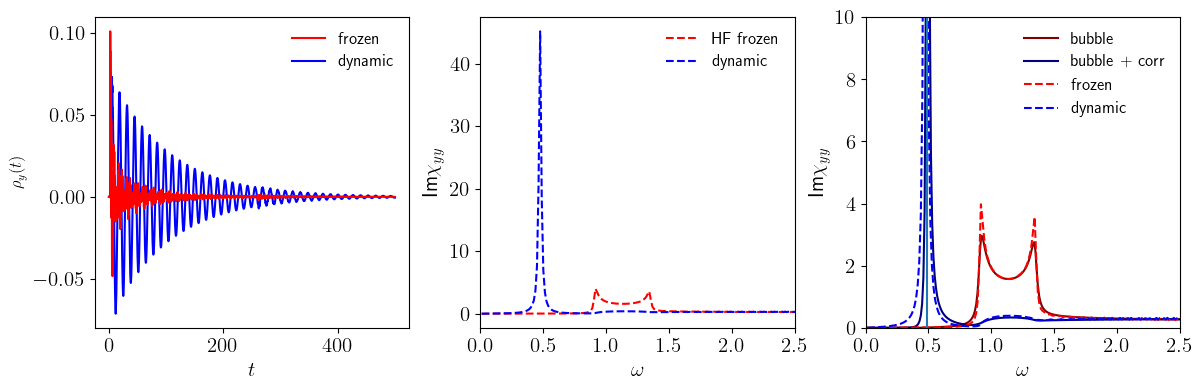

In [432]:
meas_yy = measurement[1] - measurement[1,0]
meas_yyN = measurementN[1] - measurementN[1,0]


pulz = A_pulz(time, A0, t0, sigma, Omega0)
omega_cut = 5
eta = 0.001

Omega, Signal_yy, Pulz = susceptibility(time, meas_yy, pulz, eta, omega_cut, m.Nk)
_, Signal_yyN, _ = susceptibility(timeN, meas_yyN, pulz, eta, omega_cut, m.Nk)

Chi_yy = Signal_yy / Pulz
Chi_yyN = Signal_yyN / Pulz
peakN = Omega[np.argmax(-Chi_yyN.imag)]

fig, ax = plt.subplots(ncols=3, figsize=(12,4))
ax[0].plot(timeN, meas_yy.real, color='red', label='frozen')
ax[0].plot(timeN, meas_yyN.real, color='blue', zorder=-100, label='dynamic')
ax[1].plot(Omega, -Chi_yy.imag, color='red', label='HF frozen', ls='dashed')
ax[1].plot(Omega, -Chi_yyN.imag, color='blue', label='dynamic', ls='dashed')
g = 1
ax[2].plot(omegas, chi_yy0.imag[g], color='maroon', label='bubble')
ax[2].plot(omegas, chi_yy.imag[g], color='navy', label='bubble + corr')
ax[2].plot(Omega, -Chi_yy.imag, ls='dashed', color='red', label='frozen')
ax[2].plot(Omega, -Chi_yyN.imag, ls='dashed', color='blue', label='dynamic')

ax[2].set_ylim(0,10)
for j in range(1,3):
    ax[j].set_xlim(0,2.5)
    ax[j].set_xlabel(r'$\omega$', fontsize=15)
    ax[j].set_ylabel(r'$\text{Im}\chi_{yy}$', fontsize=15)
for j in range(3):
    ax[j].legend(frameon=False)

ax[0].set_xlabel(r'$t$', fontsize=15)
ax[0].set_ylabel(r'$\rho_y(t)$')

omega_yy_max = omegas[np.argmax(chi_yy[g].imag)]
ax[2].axvline(omega_yy_max)
plt.tight_layout()

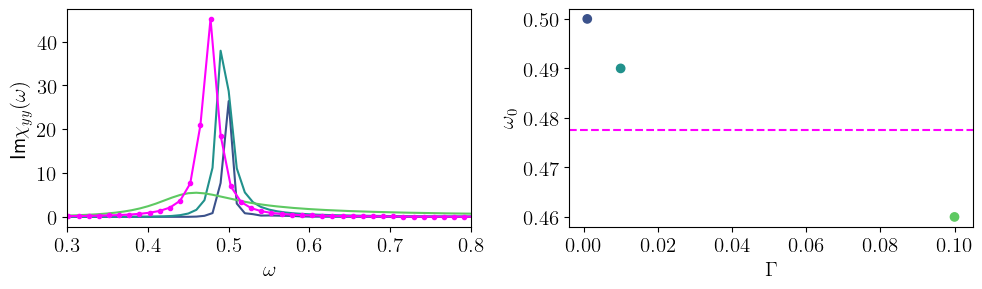

In [433]:
omega_peaks = np.zeros(len(Gammas))
col2 = get_palette_hex('viridis', len(Gammas))
fig, ax = plt.subplots(ncols=2, figsize=(10,3))
for g, Gamma in enumerate(Gammas):
    ax[0].plot(omegas, chi_yy.imag[g], color=col2[g])
    omega_max = omegas[np.argmax(chi_yy.imag[g])]
    omega_peaks[g] = omega_max
#ax[0].set_xlim(0.5,0.66)
ax[1].scatter(Gammas, omega_peaks, c=col2)
ax[1].axhline(peakN, ls='dashed', color='magenta')
ax[0].set_xlabel(r'$\omega$', fontsize=15)
ax[0].set_ylabel(r'$\text{Im}\chi_{yy}(\omega)$', fontsize=15)
ax[1].set_xlabel(r'$\Gamma$', fontsize=15)
ax[1].set_ylabel(r'$\omega_0$', fontsize=15)
#ax[0].set_ylim(0,200)
ax[0].set_xlim(0.3,0.8)
ax[0].plot(Omega, -Chi_yyN.imag, '.-', color='magenta',)
plt.tight_layout()

In [434]:
''' 5. simulate pulz with current '''
perturbation_operator = m.tok
measure_provider = m.tok

A0 = 0.003
t0 = 2.0
sigma = 0.01
Omega0 = 0.0
dt = 0.003
t_max = 500
Ncorr = 10
tol = 1e-5

Gamma = 0.0

do_freeze = True
timeJ, measurementJ, normaJ, delta_bsJ, delta_csJ = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                                             A0, t0, sigma, Omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma)

do_freeze = False
timeNJ, measurementNJ, normaNJ, delta_bsNJ, delta_csNJ = simulate_pulz(m.K, m.hk0, m.rho, m.phys_parameters, m.include_hartree, perturbation_operator, measure_provider,
                                                             A0, t0, sigma, Omega0, dt, t_max, do_freeze, Ncorr, tol, m.geom, m.phases, m.g_ffts, Gamma)

0.0
0.00030000120000480004
0.0006000024000096001
0.0009000036000144001
0.0012000048000192002
0.001500006000024
0.0018000072000288001
0.0021000084000336
0.0024000096000384003
0.0027000108000432
0.003000012000048
0.0033000132000528004
0.0036000144000576002
0.0039000156000624
0.0042000168000672
0.004500018000072
0.004800019200076801
0.0051000204000816
0.0054000216000864
0.005700022800091201
0.006000024000096
0.0063000252001008
0.006600026400105601
0.0069000276001104
0.0072000288001152005
0.007500030000120001
0.0078000312001248
0.0081000324001296
0.0084000336001344
0.0087000348001392
0.009000036000144
0.009300037200148801
0.009600038400153601
0.0099000396001584
0.0102000408001632
0.010500042000168
0.0108000432001728
0.011100044400177601
0.011400045600182401
0.0117000468001872
0.012000048000192
0.0123000492001968
0.0126000504002016
0.012900051600206401
0.013200052800211201
0.013500054000216
0.0138000552002208
0.0141000564002256
0.014400057600230401
0.014700058800235201
0.015000060000240002


In [436]:
''' check that rhos, thetas reconstruct the HF Hamiltonian '''
hartreefock = h_k(m.K, m.hk0, m.rho, m.phys_parameters, 0.0, m.include_hartree) - m.hk0
hartreefock0 = np.zeros_like(hartreefock)

rhos, thetas = rho_operators(m.K, m.phys_parameters, m.include_hartree)
rhos_tilde = operator_tilde(rhos, m.vecs)

for nu in range(len(thetas)):
    th = thetas[nu]
    rho = rhos[nu]
    rho_tilde = rhos_tilde[nu]
    suma = 0.0
    for band in range(2):
        for k in range(m.Nk):
            suma += fd(m.energije[band,k], m.mu, m.Ts[-1]) * rho_tilde[band,band,k]
    hartreefock0 += th / m.Nk * suma * rho

np.allclose(hartreefock, hartreefock0)
len(thetas)

8

In [458]:
''' 6. calculate current from RPA '''
tok_tilde = operator_tilde(m.tok, m.vecs)
rhos, thetas = rho_operators(m.K, m.phys_parameters, m.include_hartree)
rhos_tilde = operator_tilde(rhos, m.vecs)

m1,m2,m3,m4 = compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts)
mat_tilde = operator_tilde(m1+m2+m3+m4, m.vecs)

L = 20
deg = 300
nodes, weights = np.polynomial.legendre.leggauss(deg)

Gammas = [0.0025 * i for i in range(1,5)]
omegas = np.linspace(0.01, 3.0, 300)

sigma_x = np.zeros((len(Gammas), len(omegas)))
dsigma_x = np.zeros_like(sigma_x)

for g, Gamma in enumerate(Gammas):
    print(g)
    mu_ = m.mu / Gamma
    invt = Gamma / m.Ts[-1]
    for om, omega in enumerate(omegas):
        results = chi_jrho2(m.Nk, len(thetas), tok_tilde, rhos_tilde, mat_tilde, -thetas, m.energije, mu_, invt, omega, Gamma, L, nodes, weights)
        sigma_x[g,om] = results['j_j'].imag / omega
        dsigma_x[g,om] = results['dj_j'].imag / omega

0
1
2
3


Text(0, 1.5, '$q=0$ excitations')

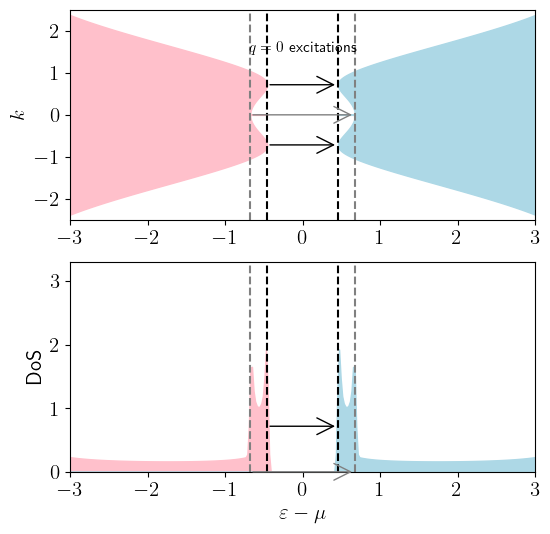

In [459]:
import scipy
def DoS(K, energije, epsilons, mu, tok_tilde, faktor, shape='Gaussian'):
    Nk = len(K)
    v_max = np.max(np.abs(tok_tilde))
    sigma = np.sqrt(v_max * (epsilons[1] - epsilons[0]) * (K[1] - K[0])) * faktor
    dos = np.zeros((2, len(epsilons)))
    for k in prange(Nk):
        for alpha in range(2):
            dos[alpha] += delta_approximation(epsilons - energije[alpha,k] + mu, sigma, shape) 
    return dos / Nk

epsilons = np.linspace(-3,3,300)
tok_tilde = operator_tilde(m.tok, m.vecs)
dos = DoS(m.K, m.energije, epsilons, m.mu, tok_tilde, 1.0)

fig, ax = plt.subplots(nrows=2, figsize=(6,6))
gap = np.min(m.energije[1]) - np.max(m.energije[0])

ax[0].fill_between(m.energije[0] - m.mu, m.K, color='pink')
ax[0].fill_between(m.energije[1] - m.mu, m.K, color='lightblue')
ax[1].fill_between(epsilons, np.zeros(epsilons.shape), dos[0], color='pink')
ax[1].fill_between(epsilons, np.zeros(epsilons.shape), dos[1], color='lightblue')

vrh1 = epsilons[scipy.signal.argrelextrema(dos[0], np.greater)]
vrh2 = epsilons[scipy.signal.argrelextrema(dos[1], np.greater)]

ind = np.argmin(np.abs(m.energije[1] - m.energije[0]))
k0 = m.K[ind]
dE_1 = m.energije[1,ind] - m.energije[0,ind]
dE_2 = m.energije[1,m.Nk//2] - m.energije[0,m.Nk//2]

for j in range(2):
    ax[j].axvline(m.energije[0,ind] - m.mu, ls='dashed', color='black')
    ax[j].axvline(m.energije[1,ind] - m.mu, ls='dashed', color='black')
    ax[j].axvline(m.energije[0,m.Nk//2] - m.mu, ls='dashed', color='grey')
    ax[j].axvline(m.energije[1,m.Nk//2] - m.mu, ls='dashed', color='grey')
    ax[j].annotate(
        "",                 # no text
        xy=(m.energije[0,ind] - m.mu, k0),           # arrow tip
        xytext=(m.energije[1,ind] - m.mu, k0),       # arrow tail
        arrowprops=dict(arrowstyle="<-", color='black', lw=1, mutation_scale=30)
    )
    ax[j].annotate(
        "",                 # no text
        xy=(m.energije[0,ind] - m.mu, m.K[m.Nk - ind]),           # arrow tip
        xytext=(m.energije[1,ind] - m.mu, m.K[m.Nk - ind]),       # arrow tail
        arrowprops=dict(arrowstyle="<-", color='black', lw=1, mutation_scale=30)
    )
    ax[j].annotate(
        "",                 # no text
        xy=(m.energije[0,m.Nk//2] - m.mu, 0),           # arrow tip
        xytext=(m.energije[1,m.Nk//2] - m.mu, 0),       # arrow tail
        arrowprops=dict(arrowstyle="<-", color='grey', lw=1, mutation_scale=30)
    )

for j in range(2):
    ax[j].set_xlim(epsilons[0], epsilons[-1])
ax[1].set_xlabel(r'$\varepsilon - \mu$', fontsize=15)
ax[0].set_ylabel(r'$k$', fontsize=15)
ax[1].set_ylabel(r'$\text{DoS}$', fontsize=15)
ax[0].set_ylim(-2.5,2.5)
ax[1].set_ylim(0,3.3)
ax[0].text(0,1.5, r'$q=0$ excitations', ha='center', fontsize=11)

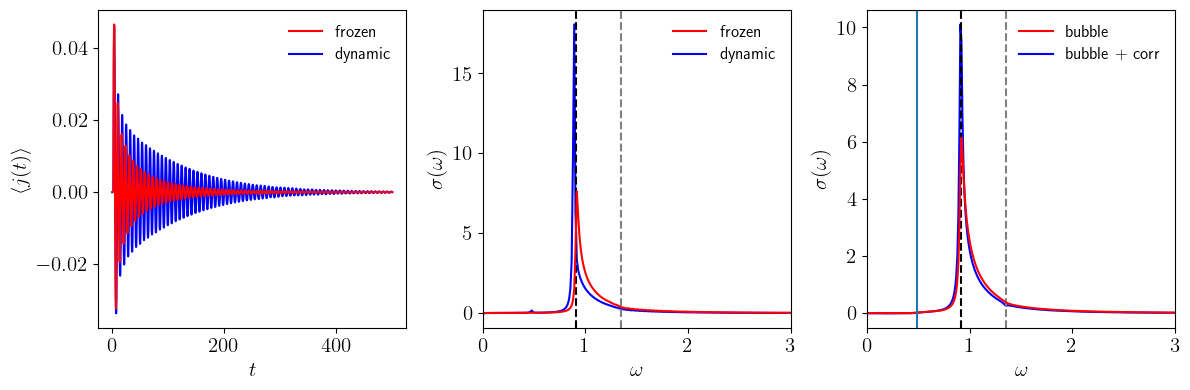

In [470]:
fig, ax = plt.subplots(ncols=3, figsize=(12,4))
gap = np.min(m.energije[1]) - np.max(m.energije[0])

measJ = measurementJ[0].real - measurementJ[0,0].real
measNJ = measurementNJ[0].real - measurementNJ[0,0].real

pulz = A_pulz(time, A0, t0, sigma, Omega0)
omega_cut = 5
eta = 0.01

Omega, Sigma = optical_conductivity(timeJ, measJ, pulz, eta, omega_cut, m.Nk)
_, SigmaN = optical_conductivity(timeJ, measNJ, pulz, eta, omega_cut, m.Nk)

ax[0].plot(timeNJ, measJ * np.exp(-eta * timeNJ), color='red', label='frozen')
ax[0].plot(timeNJ, measNJ * np.exp(-eta * timeNJ), color='blue', zorder=-100, label='dynamic')
#ax[0].set_xlim(0,200)
ax[0].set_xlabel(r'$t$', fontsize=15)
ax[0].set_ylabel(r'$\langle{j(t)\rangle}$', fontsize=15)

ax[1].plot(Omega, Sigma, color='red', label='frozen',)# ls='dashed')
ax[1].plot(Omega, SigmaN, color='blue', label='dynamic',zorder=-100)# ls='dashed')

for j in range(2):
    ax[1].set_xlim(0,4)

g = 2
ax[2].plot(omegas, sigma_x[g], color='red', label='bubble')
ax[2].plot(omegas, sigma_x[g] + dsigma_x[g], color='blue', label='bubble + corr', zorder=-100)

for j in range(3):
    ax[j].legend(frameon=False)

for j in range(1,3):
    ax[j].set_xlabel(r'$\omega$', fontsize=15)
    ax[j].set_ylabel(r'$\sigma(\omega)$', fontsize=15)
    ax[j].set_xlim(0,3)
    ax[j].axvline(dE_1, color='black', zorder=-100, ls='dashed')
    ax[j].axvline(dE_2, color='grey', zorder=-100, ls='dashed')
#ax[1].set_ylim(0,0.3)
pal = get_palette_hex('viridis', len(Gammas))

#ax[2].plot(ena, 1000 * np.imag(dve / tri))


#ax[1].set_ylim(0,0.3)
#ax[2].set_ylim(0,2)

ax[2].axvline(omega_yy_max)

plt.tight_layout()

#for g, Gamma in enumerate(Gammas):
#    if g > 1: ax[2].plot(omegas / gap, sigma_x[g] + dsigma_x[g], color=pal[g])

(0.0, 0.5)

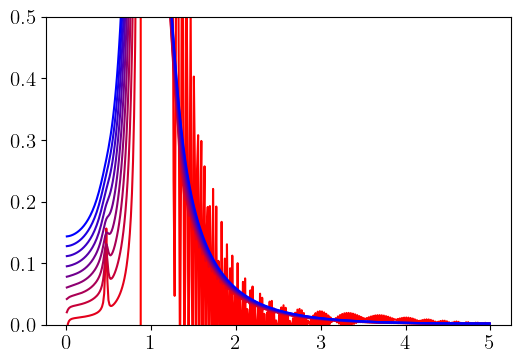

In [457]:
etas = np.linspace(0,1e-1,10)

for i, eta in enumerate(etas):

    Omega, Sigma = optical_conductivity(timeJ, measJ, pulz, eta, omega_cut, m.Nk)
    _, SigmaN = optical_conductivity(timeJ, measNJ, pulz, eta, omega_cut, m.Nk)

    plt.plot(Omega, SigmaN, color=colorFader('red', 'blue', i / (len(etas) - 1)))

plt.ylim(0,0.5)

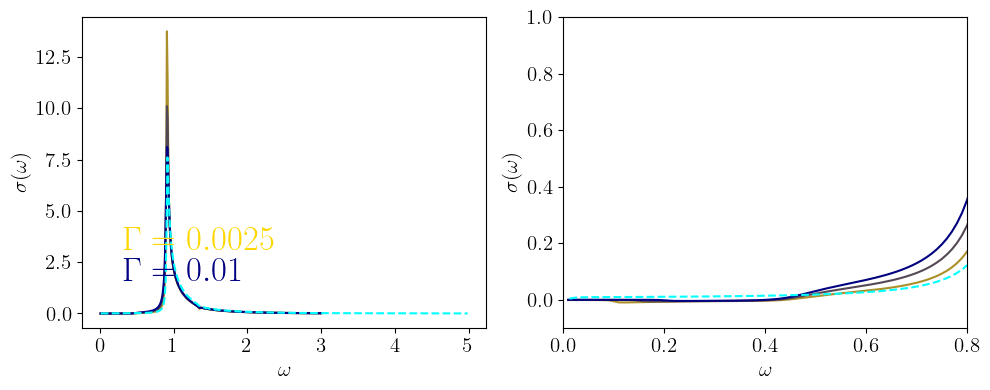

In [468]:
pal = [colorFader('gold', 'navy', i / (len(Gammas) - 1)) for i in range(len(Gammas))]
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
for g, Gamma in enumerate(Gammas):
    if g > 0:
        for j in range(2):
            ax[j].plot(omegas, sigma_x[g] +dsigma_x[g], color=pal[g])
ax[1].set_ylim(-0.1,1), ax[1].set_xlim(0,0.8)
for j in range(2):
    ax[j].set_xlabel(r'$\omega$', fontsize=15)
    ax[j].set_ylabel(r'$\sigma(\omega)$', fontsize=15)
for j in range(2):
    ax[j].plot(Omega, Sigma, color='cyan', label='dynamic', ls='dashed')

ax[0].text(0.1,0.25, rf'$\Gamma={Gammas[0]}$', color=pal[0],transform=ax[0].transAxes, fontsize=25)
ax[0].text(0.1,0.15, rf'$\Gamma={Gammas[-1]}$', color=pal[-1],transform=ax[0].transAxes, fontsize=25)

plt.tight_layout()


In [47]:
''' 4. calculate chi from RPA '''
tok_tilde = operator_tilde(m.tok, m.vecs)
rhos, thetas = rho_operators(m.K, m.phys_parameters, m.include_hartree)
rhos_tilde = operator_tilde(rhos, m.vecs)

m1,m2,m3,m4 = compute_all_mf_matrices(m.K, m.rho, m.geom, m.phases, m.g_ffts)
mat_tilde = operator_tilde(m1+m2+m3+m4, m.vecs)

L = 30
deg = 1000
nodes, weights = np.polynomial.legendre.leggauss(deg)

Gammas = np.logspace(-4,-1,20)
omegas0 = np.logspace(-5,-1,20)

sigma_x0 = np.zeros((len(Gammas), len(omegas0)))
dsigma_x0 = np.zeros_like(sigma_x0)

for g, Gamma in enumerate(Gammas):
    print(g)
    mu_ = m.mu / Gamma
    invt = Gamma / m.Ts[-1]
    for om, omega in enumerate(omegas0):
        results = chi_jrho2(m.Nk, len(thetas), tok_tilde, rhos_tilde, mat_tilde, -thetas, m.energije, mu_, invt, omega, Gamma, L, nodes, weights)
        sigma_x0[g,om] = results['j_j'].imag / omega
        dsigma_x0[g,om] = results['dj_j'].imag / omega

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [45]:
epsilons = np.linspace(-1,1,50)
m.tok_tilde = operator_tilde(m.tok, m.vecs)
mfd1 = -fd_1(epsilons, m.Ts[-1])
L11s = np.zeros(len(Gammas))
for g, Gamma in enumerate(Gammas):
    print(g)
    L11 = m.ls_kubo(epsilons, Gamma, mfd1)[0]
    L11s[g] = L11

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


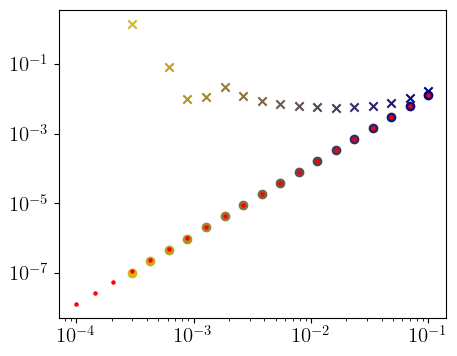

In [48]:
pal = [colorFader('gold', 'navy', i / (len(Gammas) - 1)) for i in range(len(Gammas))]
fig, ax = plt.subplots(figsize=(5,4))
for g, Gamma in enumerate(Gammas):
    if g > 2:
        plt.scatter(Gamma, sigma_x0[g,0], color=pal[g])
        plt.scatter(Gamma, sigma_x0[g,0] + dsigma_x0[g,0], color=pal[g], marker='x')
plt.xscale('log')

plt.scatter(Gammas, L11s, color='red', s=5, label='')
plt.yscale('log')

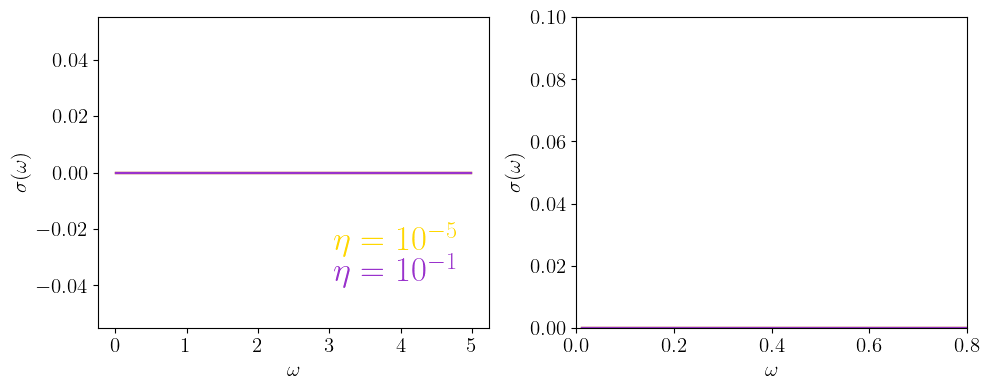

In [49]:
etas = np.linspace(1e-5, 1e-1,10)
fig, ax = plt.subplots(ncols=2, figsize=(10,4))

pal = [colorFader('gold', 'darkorchid', i / (len(etas) - 1)) for i in range(len(etas))]
meas = measurement[:,0].real - measurement[0,0].real
measN = measurementN[:,0].real - measurementN[0,0].real

pulz = A_pulz(time, A0, t0, sigma, Omega0)

for i, eta in enumerate(etas):
    Omega, Sigma = optical_conductivity(time, meas, pulz, eta, omega_cut, m.Nk)
    _, SigmaN = optical_conductivity(time, measN, pulz, eta, omega_cut, m.Nk)
    for j in range(2):
        ax[j].plot(Omega, SigmaN, color=pal[i])
ax[1].set_ylim(0,0.1), ax[1].set_xlim(0,0.8)

ax[0].text(0.6,0.25, r'$\eta=10^{-5}$', color=pal[0],transform=ax[0].transAxes, fontsize=25)
ax[0].text(0.6,0.15, r'$\eta=10^{-1}$', color=pal[-1],transform=ax[0].transAxes, fontsize=25)

for j in range(2):
    ax[j].set_xlabel(r'$\omega$', fontsize=15)
    ax[j].set_ylabel(r'$\sigma(\omega)$', fontsize=15)

plt.tight_layout()